# Wizualizacja danych z Pandas, Matplotlib i Seaborn

## 1. Import bibliotek

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Ustawienia dla czytelności wykresów
plt.rcParams.update({'font.size': 12})
sns.set_style("whitegrid")  # Styl seaborn

## 2. Przygotowanie danych

In [2]:
data = {
    "wojewodztwo": ["łódzkie", "łódzkie", "łódzkie", "łódzkie", "łódzkie",
                     "mazowieckie", "mazowieckie", "mazowieckie", "mazowieckie", "mazowieckie"],
    "rok": [2000, 2005, 2010, 2015, 2020,
            2000, 2005, 2010, 2015, 2020],
    "populacja_mln": [2.67, 2.59, 2.54, 2.49, 2.44,
                      5.07, 5.14, 5.24, 5.35, 5.42]
}
df_woj = pd.DataFrame(data)
df_woj.head(10)

,wojewodztwo,rok,populacja_mln
0,łódzkie,2000,2.67
1,łódzkie,2005,2.59
2,łódzkie,2010,2.54
3,łódzkie,2015,2.49
4,łódzkie,2020,2.44
5,mazowieckie,2000,5.07
6,mazowieckie,2005,5.14
7,mazowieckie,2010,5.24
8,mazowieckie,2015,5.35
9,mazowieckie,2020,5.42


In [3]:
df_woj.keys()

Index(['wojewodztwo', 'rok', 'populacja_mln'], dtype='object')

In [4]:
# Filtracja danych dla każdego województwa
mazowieckie = df_woj[df_woj["wojewodztwo"] == "mazowieckie"]
lodzkie = df_woj[df_woj["wojewodztwo"] == "łódzkie"]

In [5]:
lodzkie

,wojewodztwo,rok,populacja_mln
0,łódzkie,2000,2.67
1,łódzkie,2005,2.59
2,łódzkie,2010,2.54
3,łódzkie,2015,2.49
4,łódzkie,2020,2.44


## 3. WYKRES LINIOWY (Line Plot)

**Zastosowanie:** Przedstawianie zmian w czasie, trendów

(1999.0, 2021.0)

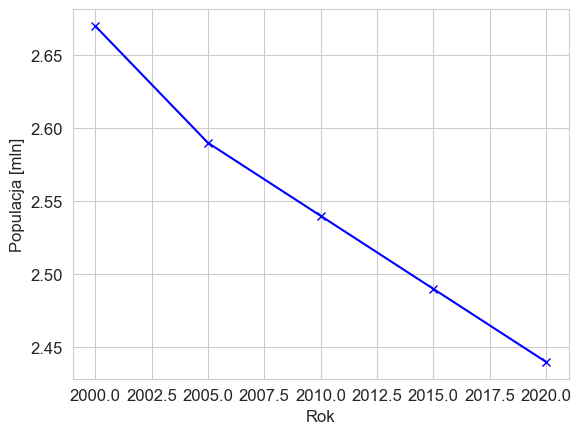

In [ ]:
plt.plot(lodzkie["rok"], lodzkie["populacja_mln"], "bx-")
plt.xlabel("Rok")
plt.ylabel("Populacja [mln]")
plt.xlim([1999, 2021])

Text(0, 0.5, 'pop [mln]')

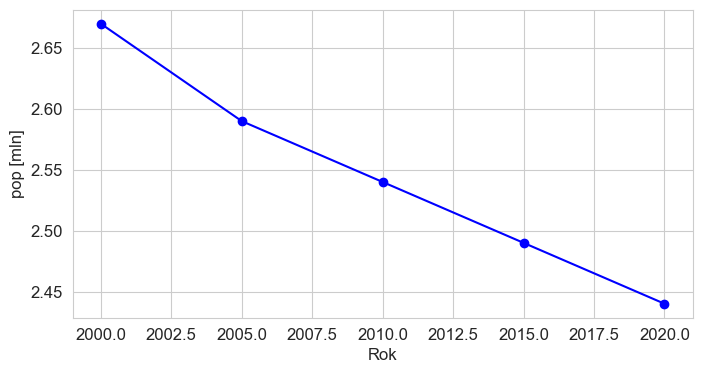

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lodzkie["rok"], lodzkie["populacja_mln"], 'bo-')
ax.set_xlabel("Rok")
ax.set_ylabel("pop [mln]")

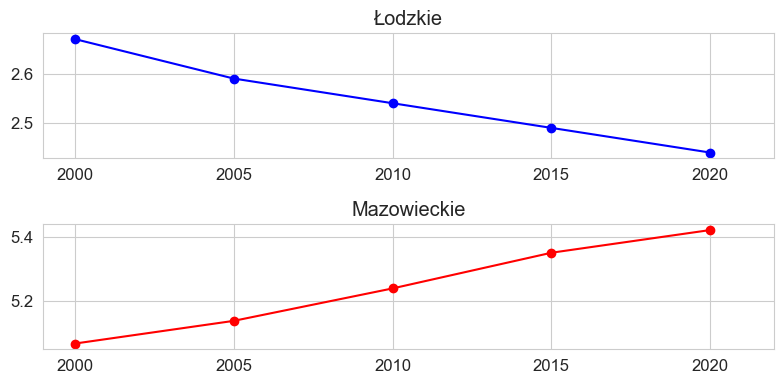

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(8, 4))
ax[0].plot(lodzkie["rok"], lodzkie["populacja_mln"], 'bo-')
ax[0].set_title("Łodzkie")
ax[1].plot(mazowieckie["rok"], mazowieckie["populacja_mln"], 'ro-')
ax[0].set_xlim([1999, 2022])
ax[1].set_xlim([1999, 2022])
ax[1].set_title("Mazowieckie")
plt.tight_layout()

### Bezpośrednio `plot` na pandas DataFrame

<Axes: xlabel='rok'>

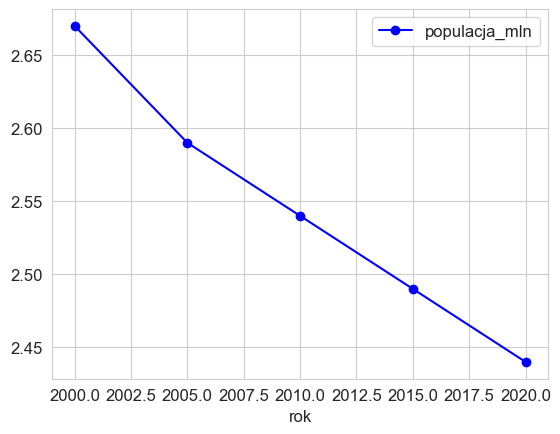

In [ ]:
lodzkie.plot(x="rok", y="populacja_mln", marker="o", color="blue")

<Axes: xlabel='rok'>

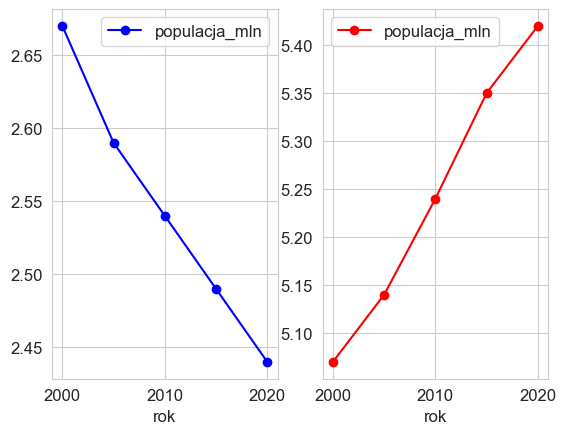

In [ ]:
fig, ax = plt.subplots(1, 2)
lodzkie.plot(x="rok", y="populacja_mln", marker="o", color="blue", ax=ax[0])
mazowieckie.plot(x="rok", y="populacja_mln", marker="o", color="red", ax=ax[1])

## 4. WYKRES PUNKTOWY (Scatter Plot)

 **Zastosowanie:** Pokazywanie relacji między dwiema zmiennymi

In [ ]:
# Generowanie dodatkowych danych dla scatter plot
np.random.seed(42)
scatter_data = pd.DataFrame({
    'temperatura': np.random.uniform(15, 35, 1500),
    'sprzedaz_lodow': np.random.uniform(50, 300, 1500)
})
# Dodajemy korelację
scatter_data['sprzedaz_lodow'] = scatter_data['sprzedaz_lodow'] + scatter_data['temperatura'] * 5

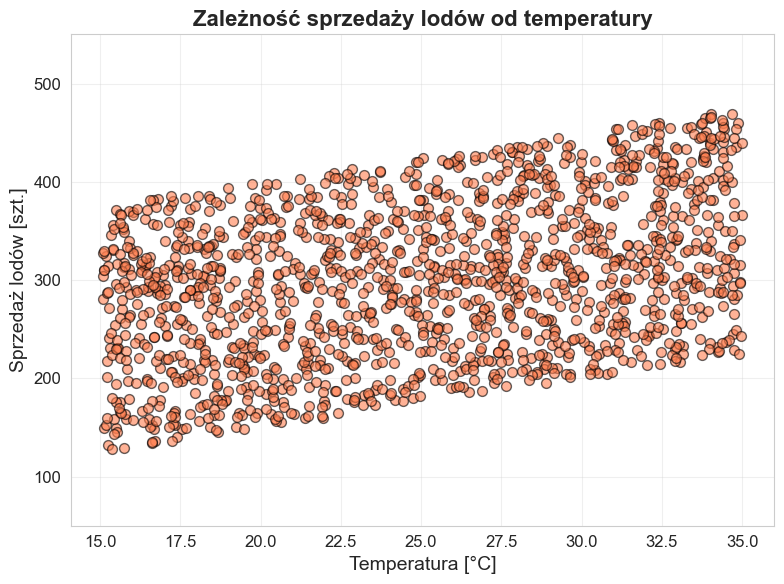

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(scatter_data['temperatura'], scatter_data['sprzedaz_lodow'],
            s=50, alpha=0.6, c='coral', edgecolors='black', linewidth=1)

plt.title('Zależność sprzedaży lodów od temperatury', fontsize=16, fontweight='bold')
plt.xlabel('Temperatura [°C]', fontsize=14)
plt.ylabel('Sprzedaż lodów [szt.]', fontsize=14)
plt.ylim([50, 550])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. WYKRES SŁUPKOWY (Bar Plot)

 **Zastosowanie:** Porównywanie wartości między kategoriami

In [ ]:
# Dane dla wykresu słupkowego - populacja miast w dwóch różnych latach
miasta_data = pd.DataFrame({
    'miasto': ['Warszawa', 'Kraków', 'Łódź', 'Wrocław', 'Poznań'],
    'populacja_2022': [1795, 800, 670, 672, 545],
    'populacja_2010': [1700, 757, 730, 632, 550]
})

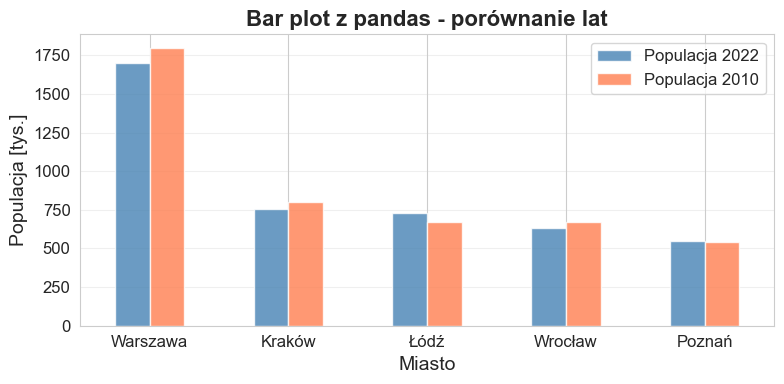

In [ ]:
# Bar plot - Pandas

miasta_data.plot.bar(x='miasto', y=['populacja_2010', 'populacja_2022'],
                     figsize=(8, 4), color=['steelblue', 'coral'], alpha=0.8)
plt.title('Bar plot z pandas - porównanie lat', fontsize=16, fontweight='bold')
plt.xlabel('Miasto', fontsize=14)
plt.ylabel('Populacja [tys.]', fontsize=14)
plt.legend(['Populacja 2022', 'Populacja 2010'], fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Jak to zrobić z Seaborn?

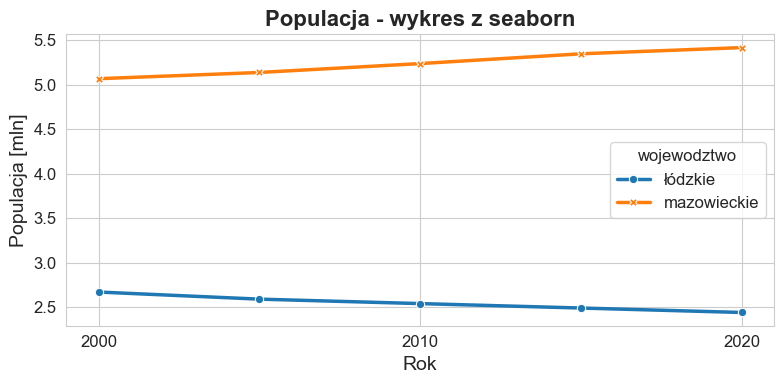

In [ ]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=df_woj, x='rok', y='populacja_mln', hue='wojewodztwo',
             style='wojewodztwo', markers=True, dashes=False, linewidth=2.5)

plt.title('Populacja - wykres z seaborn', fontsize=16, fontweight='bold')
plt.xlabel('Rok', fontsize=14)
plt.ylabel('Populacja [mln]', fontsize=14)
plt.xticks([2000, 2010, 2020])
plt.tight_layout()
plt.show()

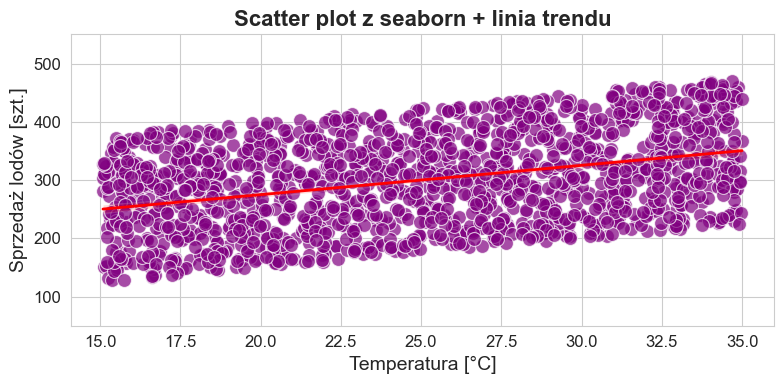

In [ ]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=scatter_data, x='temperatura', y='sprzedaz_lodow',
                s=100, alpha=0.7, color='purple')
sns.regplot(data=scatter_data, x='temperatura', y='sprzedaz_lodow',
            scatter=False, color='red', line_kws={'linewidth': 2})

plt.title('Scatter plot z seaborn + linia trendu', fontsize=16, fontweight='bold')
plt.xlabel('Temperatura [°C]', fontsize=14)
plt.ylabel('Sprzedaż lodów [szt.]', fontsize=14)
plt.ylim([50, 550])
plt.tight_layout()
plt.show()

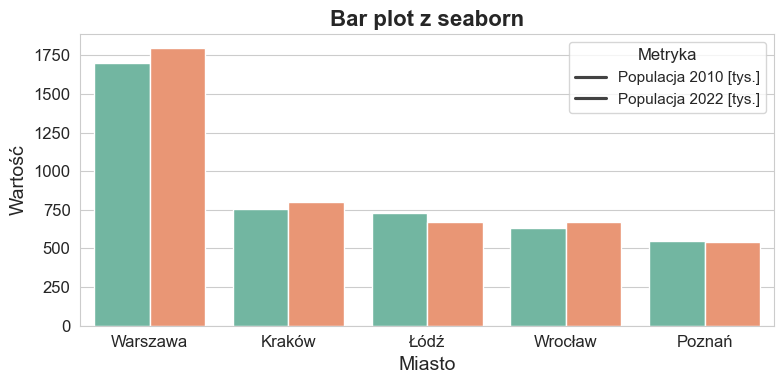

In [ ]:
# Bar plot - Seaborn

# Przekształcenie danych do formatu długiego (long format)
miasta_long = pd.melt(miasta_data, id_vars=['miasto'],
                      value_vars=['populacja_2010', 'populacja_2022'],
                      var_name='Typ', value_name='Wartość')

plt.figure(figsize=(8, 4))
sns.barplot(data=miasta_long, x='miasto', y='Wartość', hue='Typ', palette='Set2')
plt.title('Bar plot z seaborn', fontsize=16, fontweight='bold')
plt.xlabel('Miasto', fontsize=14)
plt.ylabel('Wartość', fontsize=14)
plt.legend(title='Metryka', labels=['Populacja 2010 [tys.]', 'Populacja 2022 [tys.]'], fontsize=11)
plt.tight_layout()
plt.show()

# ZADANIA


## Zadanie 1: Podstawy DataFrame i wykres liniowy

**Dane:** Liczba mieszkańców Warszawy i Łodzi w wybranych latach:

| Rok  | Warszawa  | Łódź      |
|------|-----------|-----------|
| 2002 | 1672000   | 789318    |
| 2011 | 1707000   | 728892    |
| 2015 | 1740000   | 700982    |
| 2022 | 1795000   | 670642    |

**Polecenia:**
1. Utwórz słownik z powyższymi danymi
2. Stwórz DataFrame z tego słownika
5. **Stwórz wykres liniowy** pokazujący zmiany populacji obu miast w czasie
   - Użyj różnych kolorów i markerów dla każdego miasta
    - Dodaj tytuł, opisy osi i legendę
    - Wypróbuj wszystkie 3 metody (matplotlib, pandas, seaborn)

DataFrame z danymi:
    Rok  Warszawa    Łódź
0  2002   1672000  789318
1  2011   1707000  728892
2  2015   1740000  700982
3  2022   1795000  670642



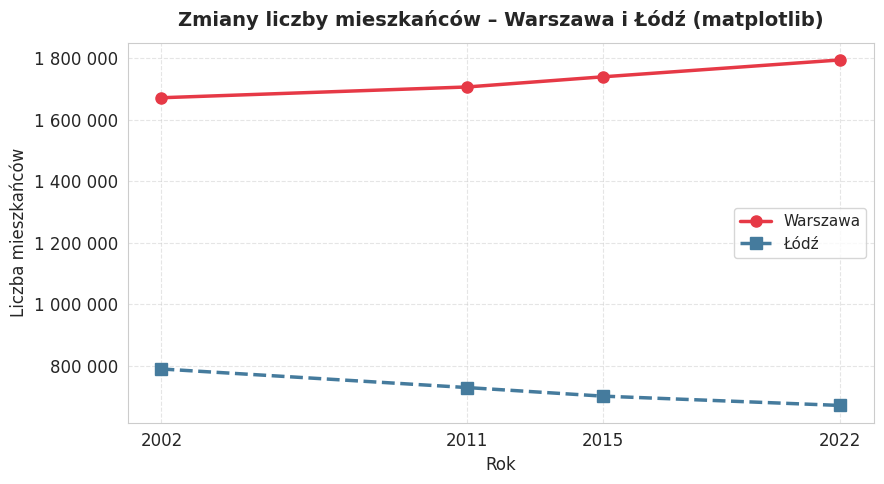

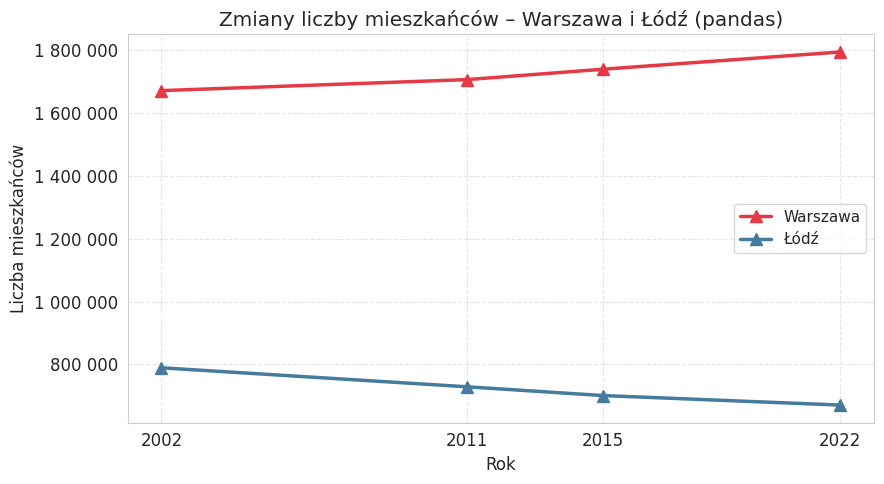

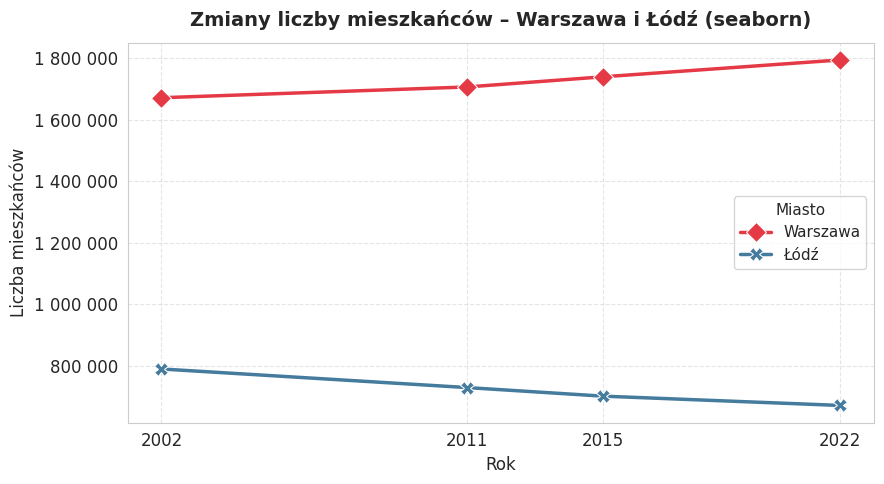

In [6]:
dane = {
    "Rok":      [2002, 2011, 2015, 2022],
    "Warszawa": [1672000, 1707000, 1740000, 1795000],
    "Łódź":    [789318,  728892,  700982,  670642],
}

df = pd.DataFrame(dane)
print("DataFrame z danymi:")
print(df)
print()


# 3a. Wykres liniowy – MATPLOTLIB

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(df["Rok"], df["Warszawa"],
        color="#E63946", marker="o", linewidth=2.5,
        markersize=8, label="Warszawa")

ax.plot(df["Rok"], df["Łódź"],
        color="#457B9D", marker="s", linewidth=2.5,
        markersize=8, linestyle="--", label="Łódź")

ax.set_title("Zmiany liczby mieszkańców – Warszawa i Łódź (matplotlib)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Rok", fontsize=12)
ax.set_ylabel("Liczba mieszkańców", fontsize=12)
ax.set_xticks(df["Rok"])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " ")))
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# 3b. Wykres liniowy – PANDAS (wbudowana metoda .plot())

ax2 = df.plot(
    x="Rok",
    y=["Warszawa", "Łódź"],
    kind="line",
    figsize=(9, 5),
    marker="^",
    color={"Warszawa": "#E63946", "Łódź": "#457B9D"},
    linewidth=2.5,
    markersize=9,
    title="Zmiany liczby mieszkańców – Warszawa i Łódź (pandas)",
)

ax2.set_xlabel("Rok", fontsize=12)
ax2.set_ylabel("Liczba mieszkańców", fontsize=12)
ax2.set_xticks(df["Rok"])
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " "))
)
ax2.legend(["Warszawa", "Łódź"], fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# 3c. Wykres liniowy – SEABORN

# Seaborn potrzebuje "długiego" formatu danych (melt)
df_long = df.melt(id_vars="Rok", var_name="Miasto", value_name="Liczba mieszkańców")

fig3, ax3 = plt.subplots(figsize=(9, 5))

sns.lineplot(
    data=df_long,
    x="Rok",
    y="Liczba mieszkańców",
    hue="Miasto",
    style="Miasto",
    markers={"Warszawa": "D", "Łódź": "X"},
    dashes=False,
    palette={"Warszawa": "#E63946", "Łódź": "#457B9D"},
    linewidth=2.5,
    markersize=10,
    ax=ax3,
)

ax3.set_title("Zmiany liczby mieszkańców – Warszawa i Łódź (seaborn)",
              fontsize=14, fontweight="bold", pad=12)
ax3.set_xlabel("Rok", fontsize=12)
ax3.set_ylabel("Liczba mieszkańców", fontsize=12)
ax3.set_xticks(df["Rok"])
ax3.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " "))
)
ax3.legend(title="Miasto", fontsize=11, title_fontsize=11)
ax3.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Zadanie 2: Analiza danych o pojazdach w Łodzi

Dane pochodzą z portalu otwartych danych miasta Łodzi: https://otwarte.miasto.lodz.pl/transport_komunikacja/

### Do zrobienia:

1. **Wczytaj plik** `Pojazdy-ogolem-w-Lodzi.csv`

2. **Utwórz wykres punktowy** pokazujący zmianę liczby:
   - samochody osobowe
   - autobusy ogółem
   
   na przestrzeni lat. Dla każdego typu zrób osobny wykres.

3. **Utwórz wykres słupkowy** dla roku 2020 przedstawiający liczbę:
   - autobusów
   - samochodów osobowych
   - samochodów ciężarowych
   - motocykli

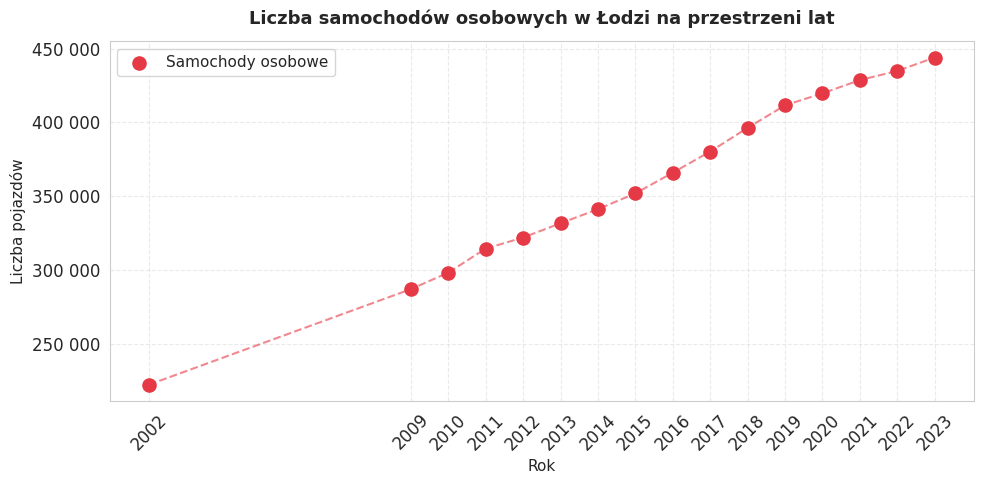

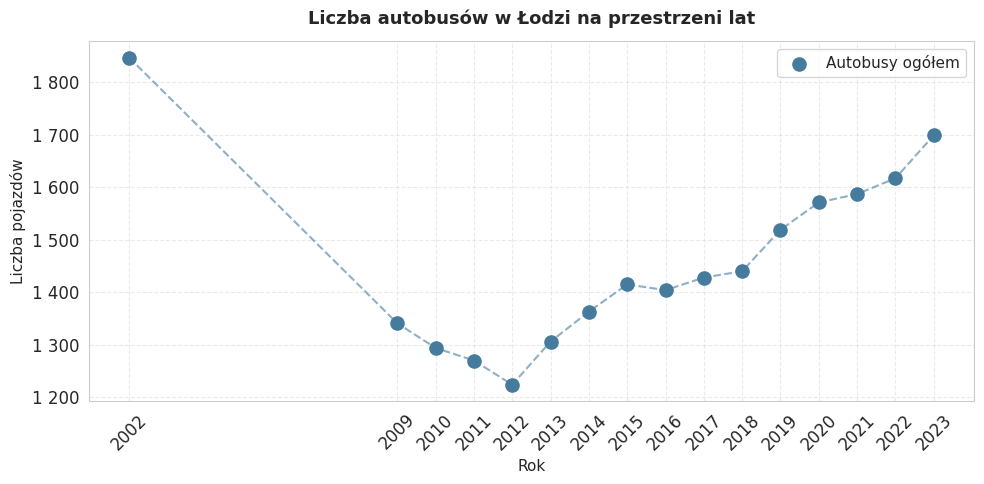

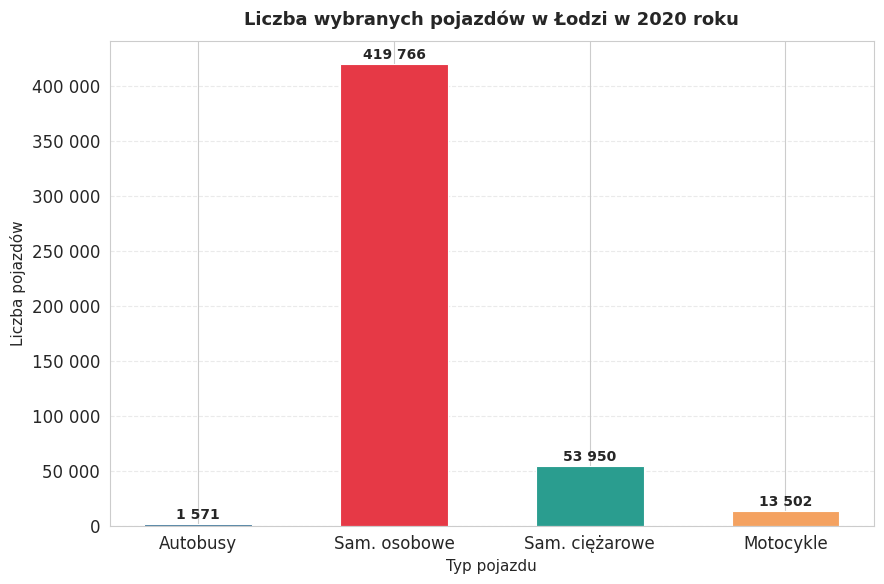

In [10]:
df = pd.read_csv("pojazdy-ogoem-w-odzi.csv", sep=";", encoding="utf-8-sig")

# 2. Wykresy punktowe – zmiana liczby pojazdów w czasie
# 2a. Samochody osobowe

osobowe = df[df["zmienne"] == "samochody osobowe"].sort_values("rok")

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(osobowe["rok"], osobowe["wartość"],
           color="#E63946", s=90, zorder=5, label="Samochody osobowe")
ax.plot(osobowe["rok"], osobowe["wartość"],
        color="#E63946", linewidth=1.5, linestyle="--", alpha=0.6)

ax.set_title("Liczba samochodów osobowych w Łodzi na przestrzeni lat",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Rok", fontsize=11)
ax.set_ylabel("Liczba pojazdów", fontsize=11)
ax.set_xticks(osobowe["rok"])
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " "))
)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# 2b. Autobusy ogółem

autobusy = df[df["zmienne"] == "autobusy ogółem"].sort_values("rok")

fig2, ax2 = plt.subplots(figsize=(10, 5))

ax2.scatter(autobusy["rok"], autobusy["wartość"],
            color="#457B9D", s=90, zorder=5, label="Autobusy ogółem")
ax2.plot(autobusy["rok"], autobusy["wartość"],
         color="#457B9D", linewidth=1.5, linestyle="--", alpha=0.6)

ax2.set_title("Liczba autobusów w Łodzi na przestrzeni lat",
              fontsize=13, fontweight="bold", pad=12)
ax2.set_xlabel("Rok", fontsize=11)
ax2.set_ylabel("Liczba pojazdów", fontsize=11)
ax2.set_xticks(autobusy["rok"])
ax2.tick_params(axis="x", rotation=45)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " "))
)
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

# 3. Wykres słupkowy – rok 2020

typy_2020 = ["autobusy ogółem", "samochody osobowe",
             "samochody ciężarowe", "motocykle ogółem"]

etykiety = ["Autobusy", "Sam. osobowe", "Sam. ciężarowe", "Motocykle"]
kolory   = ["#457B9D", "#E63946", "#2A9D8F", "#F4A261"]

df_2020 = (
    df[(df["rok"] == 2020) & (df["zmienne"].isin(typy_2020))]
    .set_index("zmienne")
    .reindex(typy_2020)
)

wartosci = df_2020["wartość"].values

fig3, ax3 = plt.subplots(figsize=(9, 6))

bars = ax3.bar(etykiety, wartosci, color=kolory, width=0.55, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, wartosci):
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2000,
        f"{int(val):,}".replace(",", " "),
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax3.set_title("Liczba wybranych pojazdów w Łodzi w 2020 roku",
              fontsize=13, fontweight="bold", pad=12)
ax3.set_xlabel("Typ pojazdu", fontsize=11)
ax3.set_ylabel("Liczba pojazdów", fontsize=11)
ax3.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " "))
)
ax3.grid(axis="y", linestyle="--", alpha=0.4)
ax3.set_axisbelow(True)

plt.tight_layout()
plt.show()